In [24]:
import numpy as np 
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [25]:
img = cv2.imread('./test_images/ronaldo.jpg')
print(type(img), img)

<class 'numpy.ndarray'> [[[ 33  28  29]
  [ 33  28  29]
  [ 33  28  29]
  ...
  [ 21  21  21]
  [ 21  21  21]
  [ 21  21  21]]

 [[ 33  28  29]
  [ 33  28  29]
  [ 33  28  29]
  ...
  [ 21  21  21]
  [ 21  21  21]
  [ 21  21  21]]

 [[ 33  28  29]
  [ 33  28  29]
  [ 33  28  29]
  ...
  [ 21  21  21]
  [ 21  21  21]
  [ 21  21  21]]

 ...

 [[239 230 217]
  [238 229 216]
  [237 229 216]
  ...
  [215 209 244]
  [215 208 245]
  [214 207 244]]

 [[238 226 220]
  [238 227 219]
  [237 228 218]
  ...
  [215 209 244]
  [215 208 245]
  [214 207 244]]

 [[238 226 222]
  [238 226 220]
  [236 227 217]
  ...
  [215 209 244]
  [215 208 245]
  [214 207 244]]]


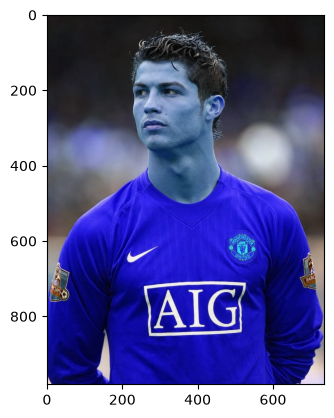

In [26]:
plt.imshow(img)

In [27]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(981, 736)

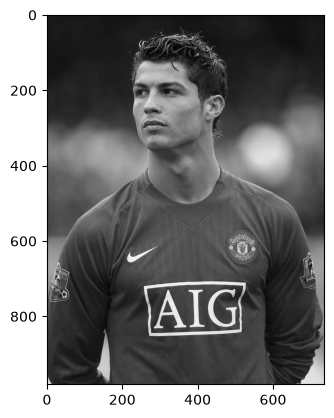

In [28]:
plt.imshow(gray, cmap='gray')

In [29]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[180, 121, 216, 216]], dtype=int32)

In [30]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(180), np.int32(121), np.int32(216), np.int32(216))

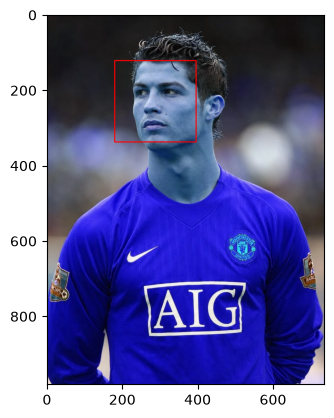

In [31]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

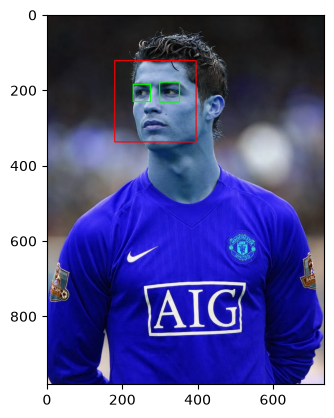

In [32]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

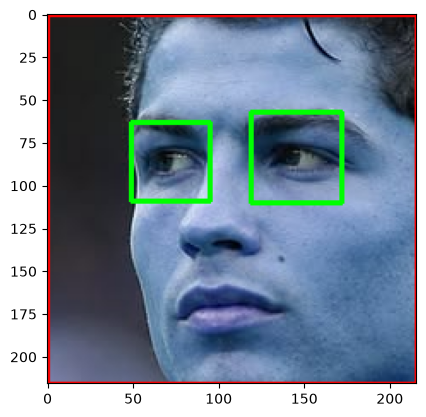

In [33]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [34]:
cropped_img = np.array(roi_color)
cropped_img.shape

(216, 216, 3)

In [35]:
import pywt

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

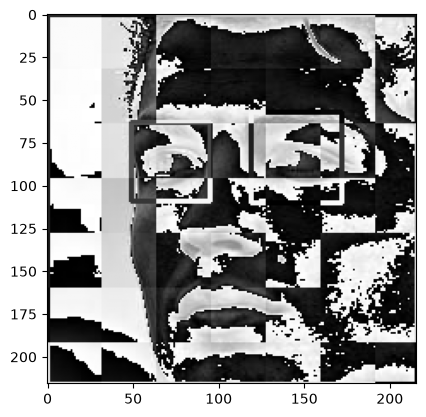

In [36]:
im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')

In [37]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

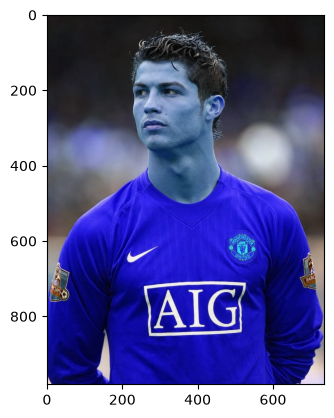

In [38]:
original_image = cv2.imread('./test_images/ronaldo.jpg')
plt.imshow(original_image)

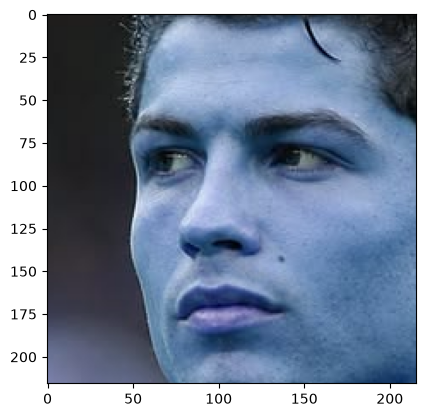

In [39]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/ronaldo.jpg')
plt.imshow(cropped_image)

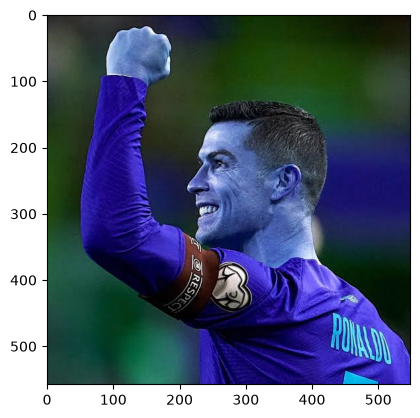

In [40]:
org_image_obstructed = cv2.imread('./test_images/ronaldo1.jpg')
plt.imshow(org_image_obstructed)

In [41]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/ronaldo1.jpg')
cropped_image_no_2_eyes

In [42]:
path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

In [43]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [44]:
img_dirs

['./dataset/cristiano_ronaldo',
 './dataset/kalyan_mbappe',
 './dataset/lamine_yamal',
 './dataset/lionel_messi',
 './dataset/mohamed_salah']

In [45]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [46]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1   

cristiano_ronaldo
Generating cropped images in folder:  ./dataset/cropped/cristiano_ronaldo
kalyan_mbappe
Generating cropped images in folder:  ./dataset/cropped/kalyan_mbappe
lamine_yamal
Generating cropped images in folder:  ./dataset/cropped/lamine_yamal
lionel_messi
Generating cropped images in folder:  ./dataset/cropped/lionel_messi
mohamed_salah
Generating cropped images in folder:  ./dataset/cropped/mohamed_salah


In [47]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{'cristiano_ronaldo': ['./dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo1.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo10.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo11.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo12.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo13.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo14.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo15.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo16.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo17.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo18.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo19.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo2.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo20.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo21.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo

In [48]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'cristiano_ronaldo': 0,
 'kalyan_mbappe': 1,
 'lamine_yamal': 2,
 'lionel_messi': 3,
 'mohamed_salah': 4}

In [49]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name]) 

In [50]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(206, 4096)

In [51]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.75

In [53]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.67      0.93      0.78        15
           1       0.50      0.56      0.53         9
           2       0.83      0.83      0.83         6
           3       1.00      0.67      0.80        12
           4       1.00      0.70      0.82        10

    accuracy                           0.75        52
   macro avg       0.80      0.74      0.75        52
weighted avg       0.80      0.75      0.75        52



In [54]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [55]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='lbfgs'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [56]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

c:\Users\Samy Elnagar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Samy Elnagar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Samy Elnagar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Samy Elnagar\AppData\Local\Programs\Python\Python314\Li

,model,best_score,best_params
0,svm,0.831183,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.642151,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.818065,{'logisticregression__C': 1}


In [57]:
best_estimators['svm'].score(X_test,y_test)

0.7884615384615384

In [58]:
best_estimators['random_forest'].score(X_test,y_test)

0.6730769230769231

In [59]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.8461538461538461

In [60]:
best_clf = best_estimators['logistic_regression']
best_clf.score(X_test, y_test)

0.8461538461538461

In [61]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[15,  0,  0,  0,  0],
       [ 2,  6,  1,  0,  0],
       [ 0,  1,  5,  0,  0],
       [ 2,  0,  0, 10,  0],
       [ 1,  0,  0,  1,  8]])

Text(95.83333333333333, 0.5, 'Truth')

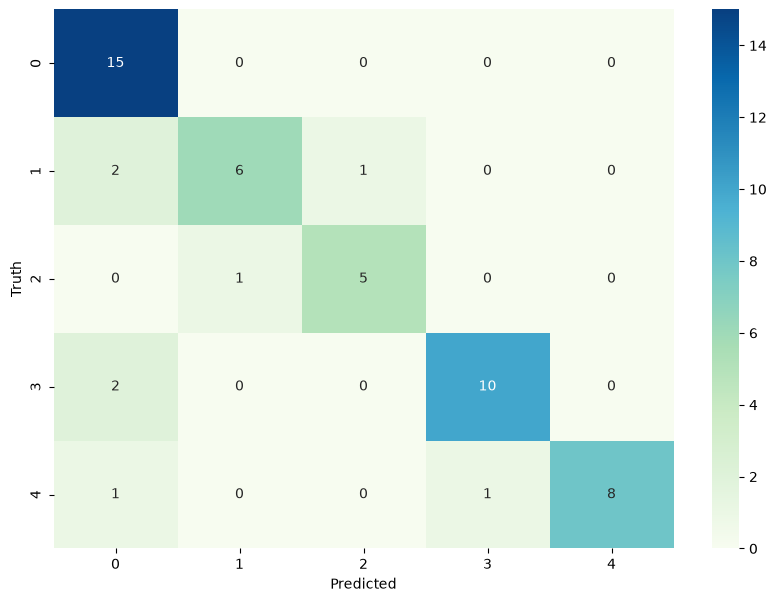

In [62]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, cmap='GnBu')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [63]:
class_dict

{'cristiano_ronaldo': 0,
 'kalyan_mbappe': 1,
 'lamine_yamal': 2,
 'lionel_messi': 3,
 'mohamed_salah': 4}

In [66]:
import pickle

with open('saved_model.pickle', 'wb') as f:
    pickle.dump(best_clf, f)

In [65]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))